# Exp 2 — baseline DQN vs HR-DQN with `config_hankel.yaml` as-is (Acrobot-v1)

A pared-down copy of [exp1_hankel.ipynb](exp1_hankel.ipynb) that runs exactly two
variants through the identical pipeline:

- **`baseline`** — `hankel_weight: 0`, i.e. *without* the HR-DQN penalty:
  `HankelDQNAgent` reproduces classical Double-DQN training exactly (same TD
  computation, same sampling distribution, no penalty machinery touched).
- **`config`** — [config_hankel.yaml](config_hankel.yaml) **as-is**
  (λ=0.01, rank r=2, window T=16, gate ρ=0.25, warm-up 2000 + ramp 2000 grad steps).

During training each run prints its **TD loss** and **Hankel penalty magnitudes**
(raw relative singular-value tail and the λ-weighted term that enters the loss)
every `PRINT_EVERY` train() calls; the full per-call series are cached and
plotted/tabulated below.

Runs are cached as `results_exp2/<variant>_s<seed>.npz`, keyed by the resolved
config — editing `config_hankel.yaml` re-runs the affected variants automatically.
In particular, flipping **`hankel_log: true`** computes the penalty on the signed
log `sign(Q)·log1p(|Q|)` of each window's value sequence instead of the raw
Q-values (Q can be negative/zero, so a plain log is undefined).

## Imports

In [1]:
import json, pathlib, random, sys, time

import numpy as np
import torch
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from experiment import load_config, build_env, build_agent, train
from agents.hankel_dqn_agent import HankelDQNAgent
from analysis.low_rank.hankel_policy import collect_hankel_sequences, _hankel_from_sequence
from analysis.low_rank.rank import compute_rank_metrics
from training import _greedy_episode_return

## Config

In [2]:
cfg = load_config("config_hankel.yaml")
print("device:", cfg["experiment"]["_device"])
cfg["agent"]

device: cuda


{'replay_buffer_capacity': 10000,
 'batch_size': 128,
 'nn_learning_rate': 0.0003,
 'eps_start': 1.0,
 'eps_min': 0.05,
 'decay_rate': 0.99995,
 'discount_factor': 0.99,
 'TD_LR': 0.005,
 'buffer_util': 1,
 'gd_steps_ceil': 1,
 'grad_clip_norm': 10.0,
 'hankel_weight': 1,
 'hankel_order': 3,
 'window_len': 16,
 'n_windows': 8,
 'gate_threshold': 1,
 'hankel_log': True,
 'warmup_grad_steps': 500,
 'ramp_grad_steps': 1,
 'window_half_life': None}

## Environment and Q-network

In [3]:
env0 = build_env(cfg)
print("obs_dim:", env0.observation_space.shape[0], "n_actions:", env0.action_space.n)
env0.close()

obs_dim: 6 n_actions: 3


In [4]:
class QNetwork(torch.nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by the agent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [torch.nn.Linear(last, h), torch.nn.ReLU()]
            last = h
        layers.append(torch.nn.Linear(last, out_dim))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Benchmark: baseline vs config (cached, keyed by the resolved config)

In [5]:
ENV_NAME = "Acrobot-v1"

In [6]:
VARIANTS = {
    "config":   {},                       # config_hankel.yaml as-is
    "baseline": dict(hankel_weight=0.0),  # exact classical Double-DQN through the same pipeline
}
SEEDS = [0, 1, 2, 3]
RESULTS = pathlib.Path("results_exp2")
RESULTS.mkdir(exist_ok=True)
PRINT_EVERY = 2000  # train() calls between TD-loss / Hankel-penalty prints


def resolve_cfg(overrides, seed):
    cfg = load_config("config_hankel.yaml")
    cfg["experiment"]["seed"] = seed
    cfg["agent"].update(overrides)
    cfg["analysis"] = {"ep_freq": 10 ** 9, "methods": []}  # analysis off inside benchmark runs
    return cfg


def cache_key(cfg):
    """Canonical JSON of every outcome-determining config section (device and the
    disabled analysis block excluded): a cached run re-runs automatically once
    config_hankel.yaml no longer matches what produced the npz."""
    parts = {k: cfg[k] for k in ("environment", "network", "agent", "training")}
    parts["seed"] = cfg["experiment"]["seed"]
    return json.dumps(parts, sort_keys=True, default=str)


def is_cached(path, key):
    if not path.exists():
        return False
    with np.load(path) as d:
        return "cfg_json" in d.files and str(d["cfg_json"]) == key


def run_one(cfg, out_path, tag):
    seed = cfg["experiment"]["seed"]
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = build_env(cfg)
    nn_extra = {"in_dim": env.observation_space.shape[0], "out_dim": env.action_space.n,
                "hidden_sizes": cfg["network"]["hidden_sizes"]}
    agent = build_agent(cfg, env, q_network=QNetwork, nn_extra_kwargs=nn_extra,
                        agent_cls=HankelDQNAgent)
    diags = []
    def train_hook(_orig=agent.train):
        d = _orig()
        if d is not None:
            diags.append(d)
            if len(diags) % PRINT_EVERY == 0:  # rolling TD-loss / Hankel-magnitude report
                w = diags[-PRINT_EVERY:]
                msg = f"[{tag}] train {len(diags):6d}: TD loss {np.mean([x['td_loss'] for x in w]):.4f}"
                raw = [x["penalty_raw"] for x in w if np.isfinite(x["penalty_raw"])]
                if raw:
                    msg += (f" | Hankel raw {np.mean(raw):.4f}"
                            f", weighted {np.mean([x['penalty_weighted'] for x in w]):.3e}"
                            f" (lambda_eff {w[-1]['lambda_eff']:.3g})")
                print(msg)
        return d
    agent.train = train_hook

    rewards = train(cfg, agent, env)

    eps = agent.epsilon
    agent.epsilon = 0.0  # greedy eval + on-policy probe
    evals = [_greedy_episode_return(agent, env, seed=30_000 + i) for i in range(20)]
    seqs = collect_hankel_sequences(agent, env, seed=777)
    eff_rank_q = compute_rank_metrics(_hankel_from_sequence(np.asarray(seqs["Hankel Q"])))[0]
    agent.epsilon = eps

    diag_arrays = ({f"diag_{k}": np.array([d[k] for d in diags], float) for k in diags[0]}
                   if diags else {})
    np.savez(out_path, rewards=np.array(rewards, float), evals=np.array(evals, float),
             eff_rank_q=eff_rank_q, nan_skips=agent.nan_skips, cfg_json=cache_key(cfg),
             **diag_arrays)
    env.close()


for variant, ov in VARIANTS.items():
    for seed in SEEDS:
        out = RESULTS / f"{variant}_s{seed}.npz"
        cfg_run = resolve_cfg(ov, seed)
        key = cache_key(cfg_run)
        if is_cached(out, key):
            print("cached:", out.name)
            continue
        if out.exists():
            print("config changed -> re-running:", out.name)
        t0 = time.time()
        run_one(cfg_run, out, tag=f"{variant}_s{seed}")
        print(f"{out.name}: {time.time() - t0:.0f}s")

cached: config_s0.npz
cached: config_s1.npz
cached: config_s2.npz
cached: config_s3.npz
cached: baseline_s0.npz
cached: baseline_s1.npz
cached: baseline_s2.npz
cached: baseline_s3.npz


## Learning curves

In [7]:
data = {v: [np.load(RESULTS / f"{v}_s{s}.npz") for s in SEEDS] for v in VARIANTS}
COLORS = {"baseline": "tab:grey", "config": "tab:green"}

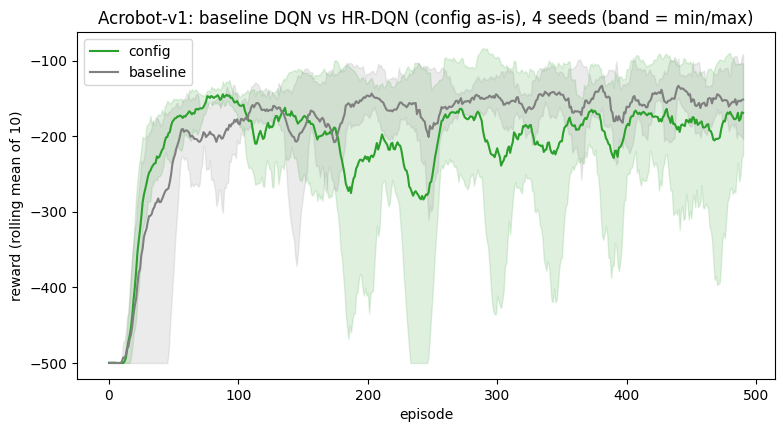

In [8]:
plt.figure(figsize=(9, 4.5))
for v, runs in data.items():
    L = min(len(r["rewards"]) for r in runs)
    R = np.stack([np.convolve(r["rewards"][:L], np.ones(10) / 10, "valid") for r in runs])
    m = R.mean(0)
    plt.plot(m, color=COLORS[v], label=v)
    plt.fill_between(range(len(m)), R.min(0), R.max(0), color=COLORS[v], alpha=0.15)
plt.xlabel("episode"); plt.ylabel("reward (rolling mean of 10)")
plt.title(f"{ENV_NAME}: baseline DQN vs HR-DQN (config as-is), {len(SEEDS)} seeds (band = min/max)")
plt.legend(); plt.show()

## TD loss and Hankel penalty magnitudes

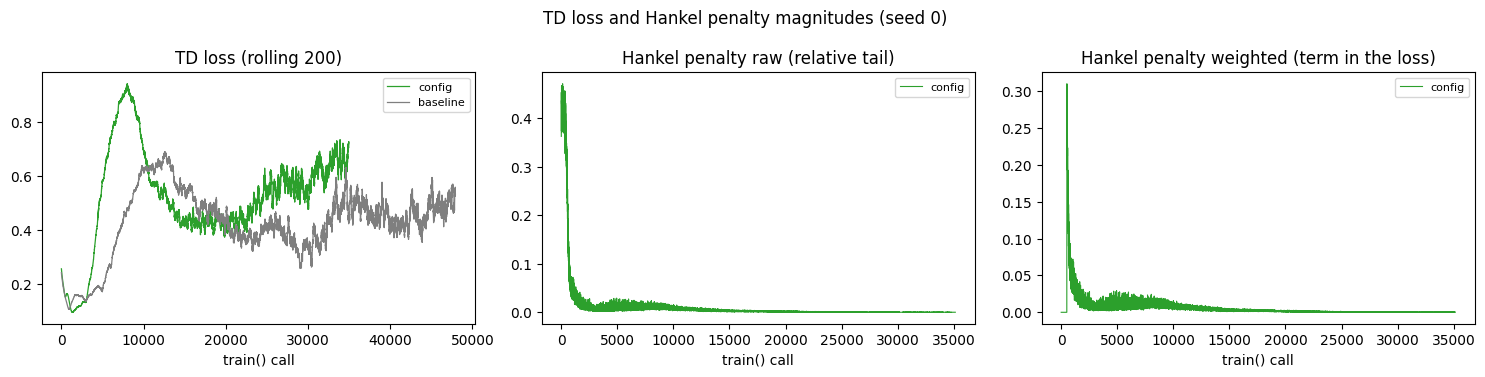

         run    TD loss   Hankel raw     weighted
   config_s0     0.6682       0.0001    1.345e-04
   config_s1     0.2450       0.0003    2.794e-04
   config_s2     0.5978       0.0006    6.355e-04
   config_s3     0.4421       0.0003    2.896e-04
 baseline_s0     0.4958            -            -
 baseline_s1     0.5467            -            -
 baseline_s2     0.5976            -            -
 baseline_s3     0.4983            -            -


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for v, runs in data.items():
    r = runs[0]  # seed 0, same convention as exp1_hankel's forensics
    axes[0].plot(np.convolve(r["diag_td_loss"], np.ones(200) / 200, "valid"),
                 color=COLORS[v], lw=0.9, label=v)
    if not np.all(np.isnan(r["diag_penalty_raw"])):
        axes[1].plot(r["diag_penalty_raw"], color=COLORS[v], lw=0.8, label=v)
        axes[2].plot(r["diag_penalty_weighted"], color=COLORS[v], lw=0.8, label=v)
for ax, lab in zip(axes, ["TD loss (rolling 200)", "Hankel penalty raw (relative tail)",
                          "Hankel penalty weighted (term in the loss)"]):
    ax.set_title(lab); ax.set_xlabel("train() call"); ax.legend(fontsize=8)
plt.suptitle("TD loss and Hankel penalty magnitudes (seed 0)")
plt.tight_layout(); plt.show()

# Printed magnitudes for every run: means over the last PRINT_EVERY train() calls.
print(f"{'run':>12s} {'TD loss':>10s} {'Hankel raw':>12s} {'weighted':>12s}")
for v, runs in data.items():
    for s, r in zip(SEEDS, runs):
        td = np.mean(r["diag_td_loss"][-PRINT_EVERY:])
        raw = r["diag_penalty_raw"][-PRINT_EVERY:]
        raw = raw[np.isfinite(raw)]
        if raw.size:
            wgt = np.mean(r["diag_penalty_weighted"][-PRINT_EVERY:])
            print(f"{v + '_s' + str(s):>12s} {td:10.4f} {raw.mean():12.4f} {wgt:12.3e}")
        else:
            print(f"{v + '_s' + str(s):>12s} {td:10.4f} {'-':>12s} {'-':>12s}")

## Final evaluation — 20 greedy episodes per run

In [10]:
print(f"{'variant':10s} {'eval20 mean±std':>22s} {'episodes to stop':>18s} {'final Hankel-Q eff-rank':>25s} {'nan_skips':>10s}")
for v, runs in data.items():
    means = np.array([r["evals"].mean() for r in runs])
    eps_used = [len(r["rewards"]) for r in runs]
    ranks = [int(r["eff_rank_q"]) for r in runs]
    skips = sum(int(r["nan_skips"]) for r in runs)
    print(f"{v:10s} {means.mean():13.1f} ± {means.std():5.1f} {str(eps_used):>18s} {str(ranks):>25s} {skips:>10d}")

variant           eval20 mean±std   episodes to stop   final Hankel-Q eff-rank  nan_skips
config            -220.6 ± 128.8 [500, 500, 500, 500]              [1, 1, 1, 1]          0
baseline          -241.0 ± 156.7 [500, 500, 500, 500]              [1, 1, 1, 1]          0
